# 4. Time--Temperature Superposition

A laboratory experiment covers only a finite time or frequency window. If temperature changes the rates of all relevant relaxation mechanisms by the same factor, measurements at several temperatures can be shifted onto a master curve covering many more decades.

## Learning outcomes

- define thermorheological simplicity and a horizontal shift factor;
- distinguish reduced time from reduced frequency;
- construct a master curve from multi-temperature data;
- fit the temperature dependence of shift factors using the WLF equation;
- diagnose failure of time--temperature superposition.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, curve_fit

plt.rcParams.update({"figure.figsize": (7.0, 4.4), "axes.grid": True})


## 4.1 Reduced variables and shift convention

Let $T_{\mathrm{ref}}$ be the reference temperature and $a_T$ the horizontal shift factor. This notebook uses

$$
t_r=\frac{t}{a_T},
\qquad
\omega_r=a_T\omega.
$$

Thus frequency-domain data measured at $T$ are plotted at $\omega_r=a_T\omega$ to compare them with data at $T_{\mathrm{ref}}$. By definition, $a_{T_{\mathrm{ref}}}=1$.

For a thermorheologically simple material,

$$
E^*(\omega,T)=E^*_{\mathrm{master}}(a_T\omega,T_{\mathrm{ref}}).
$$

This is a strong model assumption: the temperature changes the timescales but not the shape or relative strengths of the relaxation spectrum.


## 4.2 Models for the shift factor

Near the glass-transition region, the Williams--Landel--Ferry equation is commonly written

$$
\log_{10}a_T
=-\frac{C_1(T-T_{\mathrm{ref}})}{C_2+(T-T_{\mathrm{ref}})},
$$

where $C_1$ is dimensionless and $C_2$ has temperature units. Temperature differences have the same numerical value in kelvin and degrees Celsius.

Over a range governed by a single activated process, an Arrhenius relation may be more suitable:

$$
\ln a_T=\frac{E_a}{R}
\left(\frac{1}{T}-\frac{1}{T_{\mathrm{ref}}}\right),
$$

where absolute temperatures must be used, $E_a$ is an activation energy, and $R$ is the gas constant.


## 4.3 Synthetic multi-temperature experiment

We use a two-mode generalized Maxwell model as the reference master curve:

$$
E^*_{\mathrm{master}}(\omega)
=E_\infty+\sum_{i=1}^{2}
E_i\frac{i\omega\tau_i}{1+i\omega\tau_i}.
$$

Each temperature sweep covers the same instrument window. The WLF shift moves that window across the master response. Random noise is included to make shift estimation nontrivial; the data are synthetic, not measurements of a named material.


In [2]:
def generalized_maxwell(omega, Einf, mode_moduli, relaxation_times):
    omega = np.asarray(omega, dtype=float)
    response = np.full(omega.shape, complex(Einf), dtype=complex)
    for E_i, tau_i in zip(mode_moduli, relaxation_times):
        x = omega * tau_i
        response += E_i * (1j * x) / (1.0 + 1j * x)
    return response

def wlf_log10_a(T_C, C1, C2, Tref_C=40.0):
    delta_T = np.asarray(T_C, dtype=float) - Tref_C
    return -C1 * delta_T / (C2 + delta_T)

Tref_C = 40.0
temperatures_C = np.arange(20.0, 81.0, 10.0)
omega_lab = np.geomspace(1e-2, 1e3, 45)
C1_true, C2_true = 5.2, 120.0
master_parameters = {
    "Einf": 30.0,
    "mode_moduli": (75.0, 110.0),
    "relaxation_times": (0.05, 30.0),
}

rng = np.random.default_rng(44)
records = []
for T_C in temperatures_C:
    log10_a = wlf_log10_a(T_C, C1_true, C2_true, Tref_C)
    a_T = 10.0**log10_a
    omega_reduced = a_T * omega_lab
    E_star = generalized_maxwell(omega_reduced, **master_parameters)
    relative_noise = 0.012
    Ep = E_star.real * (1.0 + rng.normal(0.0, relative_noise, omega_lab.size))
    Epp = E_star.imag * (1.0 + rng.normal(0.0, relative_noise, omega_lab.size))
    for omega_i, Ep_i, Epp_i in zip(omega_lab, Ep, Epp):
        records.append((T_C, omega_i, Ep_i, Epp_i, log10_a))

data = pd.DataFrame(records, columns=[
    "temperature_C", "omega_rad_s", "storage_MPa", "loss_MPa", "true_log10_aT"
])
data.head()


,temperature_C,omega_rad_s,storage_MPa,loss_MPa,true_log10_aT
0,20.0,0.010000,132.964076,30.943941,1.04
1,20.0,0.012991,134.457532,25.313828,1.04
2,20.0,0.016876,137.084544,19.610486,1.04
3,20.0,0.021923,139.816734,15.926385,1.04
4,20.0,0.028480,140.151741,12.670952,1.04


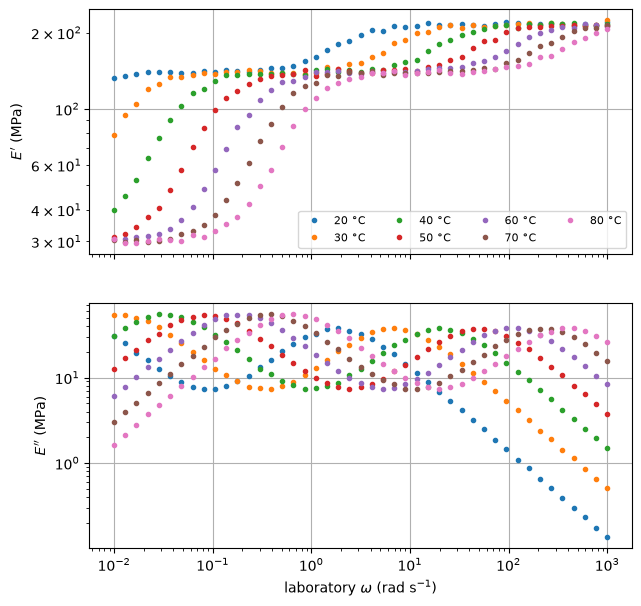

In [3]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
for T_C, group in data.groupby("temperature_C"):
    label = f"{T_C:.0f} °C"
    ax0.loglog(group["omega_rad_s"], group["storage_MPa"], marker="o", ms=3,
               linestyle="none", label=label)
    ax1.loglog(group["omega_rad_s"], group["loss_MPa"], marker="o", ms=3,
               linestyle="none")
ax0.set_ylabel("$E'$ (MPa)")
ax0.legend(ncol=4, fontsize=8)
ax1.set(xlabel=r"laboratory $\omega$ (rad s$^{-1}$)", ylabel="$E''$ (MPa)")
plt.show()


Before shifting, the temperature sweeps occupy different horizontal positions. We now estimate one $\log_{10}a_T$ for each temperature by minimizing the mismatch of both $E'$ and $E''$ with interpolated reference-temperature data.

The optimization is performed in logarithmic frequency and logarithmic modulus because the experiment spans several decades. Only overlapping frequency points contribute to each trial shift.


In [4]:
reference = data[data["temperature_C"] == Tref_C].sort_values("omega_rad_s")
x_ref = np.log10(reference["omega_rad_s"].to_numpy())
log_Ep_ref = np.log10(reference["storage_MPa"].to_numpy())
log_Epp_ref = np.log10(reference["loss_MPa"].to_numpy())

def shift_objective(log10_a, group):
    x_shifted = np.log10(group["omega_rad_s"].to_numpy()) + log10_a
    overlap = (x_shifted >= x_ref.min()) & (x_shifted <= x_ref.max())
    if overlap.sum() < 12:
        return 1e6
    Ep_target = np.interp(x_shifted[overlap], x_ref, log_Ep_ref)
    Epp_target = np.interp(x_shifted[overlap], x_ref, log_Epp_ref)
    r_storage = np.log10(group["storage_MPa"].to_numpy()[overlap]) - Ep_target
    r_loss = np.log10(group["loss_MPa"].to_numpy()[overlap]) - Epp_target
    return np.mean(np.concatenate((r_storage, r_loss))**2)

estimated_log10_a = {}
for T_C, group in data.groupby("temperature_C"):
    if T_C == Tref_C:
        estimated_log10_a[T_C] = 0.0
    else:
        result = minimize_scalar(
            shift_objective,
            bounds=(-2.5, 2.5),
            args=(group.sort_values("omega_rad_s"),),
            method="bounded",
        )
        estimated_log10_a[T_C] = result.x

shift_table = pd.DataFrame({
    "temperature_C": temperatures_C,
    "estimated_log10_aT": [estimated_log10_a[T] for T in temperatures_C],
    "true_log10_aT": [wlf_log10_a(T, C1_true, C2_true, Tref_C) for T in temperatures_C],
})
shift_table["error"] = shift_table["estimated_log10_aT"] - shift_table["true_log10_aT"]
shift_table


,temperature_C,estimated_log10_aT,true_log10_aT,error
0,20.0,1.040936,1.040000,0.000936
1,30.0,0.471175,0.472727,-0.001552
2,40.0,0.000000,-0.000000,0.000000
3,50.0,-0.399175,-0.400000,0.000825
4,60.0,-0.744383,-0.742857,-0.001526
5,70.0,-1.041495,-1.040000,-0.001495
6,80.0,-1.299387,-1.300000,0.000613


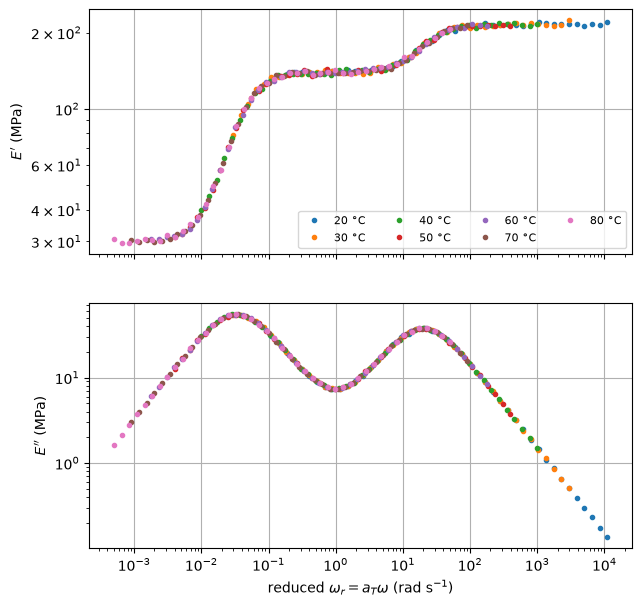

In [5]:
data["estimated_log10_aT"] = data["temperature_C"].map(estimated_log10_a)
data["omega_reduced_rad_s"] = data["omega_rad_s"] * 10.0**data["estimated_log10_aT"]

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
for T_C, group in data.groupby("temperature_C"):
    label = f"{T_C:.0f} °C"
    ax0.loglog(group["omega_reduced_rad_s"], group["storage_MPa"],
               marker="o", ms=3, linestyle="none", label=label)
    ax1.loglog(group["omega_reduced_rad_s"], group["loss_MPa"],
               marker="o", ms=3, linestyle="none")
ax0.set_ylabel("$E'$ (MPa)")
ax0.legend(ncol=4, fontsize=8)
ax1.set(xlabel=r"reduced $\omega_r=a_T\omega$ (rad s$^{-1}$)",
        ylabel="$E''$ (MPa)")
plt.show()


The shifted measurements now form approximate storage- and loss-modulus master curves. The collapse is not exact because the synthetic measurements contain noise and the shifts were estimated from a finite reference window.

## 4.4 Fit the WLF temperature dependence

The individual shifts are experimental parameters. The next step fits their temperature dependence rather than fixing $C_1$ and $C_2$ in advance.


In [6]:
mask = shift_table["temperature_C"] != Tref_C
T_fit = shift_table.loc[mask, "temperature_C"].to_numpy()
loga_fit = shift_table.loc[mask, "estimated_log10_aT"].to_numpy()

def wlf_for_fit(T_C, C1, C2):
    return wlf_log10_a(T_C, C1, C2, Tref_C=Tref_C)

popt, pcov = curve_fit(
    wlf_for_fit,
    T_fit,
    loga_fit,
    p0=(4.0, 100.0),
    bounds=([0.1, 40.0], [20.0, 500.0]),
)
C1_fit, C2_fit = popt
wlf_parameters = pd.DataFrame({
    "parameter": ["C1", "C2 (°C)"],
    "true_value": [C1_true, C2_true],
    "fitted_value": popt,
    "standard_error": np.sqrt(np.diag(pcov)),
})
wlf_parameters


,parameter,true_value,fitted_value,standard_error
0,C1,5.2,5.199999,0.017268
1,C2 (°C),120.0,119.949668,0.435382


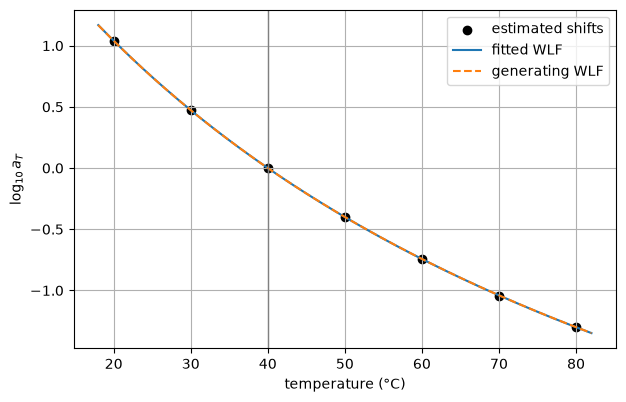

In [7]:
T_plot = np.linspace(18.0, 82.0, 400)
fig, ax = plt.subplots()
ax.scatter(shift_table["temperature_C"], shift_table["estimated_log10_aT"],
           color="black", label="estimated shifts")
ax.plot(T_plot, wlf_for_fit(T_plot, C1_fit, C2_fit), label="fitted WLF")
ax.plot(T_plot, wlf_for_fit(T_plot, C1_true, C2_true), linestyle="--",
        label="generating WLF")
ax.axvline(Tref_C, color="gray", linewidth=1)
ax.set(xlabel="temperature (°C)", ylabel=r"$\log_{10}a_T$")
ax.legend()
plt.show()


## 4.5 Validation and failure modes

Time--temperature superposition should be treated as a testable reduction, not an automatic plotting operation. Evidence against thermorheological simplicity includes:

- $E'$ and $E''$ requiring different horizontal shifts;
- temperature-dependent changes in peak height or curve shape;
- different relaxation mechanisms requiring different shift factors;
- crystallization, curing, aging, phase separation, or chemical degradation during the experiment;
- systematic master-curve residuals after experimental uncertainty is considered.

Some analyses include a vertical factor $b_T$ for density or modulus changes. It should not be introduced merely to conceal a failed horizontal collapse.

## Exercises

1. Estimate shifts using only $E'$ and then only $E''$. Compare the two shift tables.
2. Change the reference temperature. Show that the master-curve shape is unchanged while the numerical shift factors change.
3. Generate data in which only one relaxation time follows WLF. Demonstrate the failure of a single horizontal shift.
4. Fit the estimated shifts to the Arrhenius equation using kelvin. Compare its residuals with the WLF fit.
5. Replace interpolation against one reference sweep with a global fit of the master curve and all shift factors. What additional identifiability constraints are required?

The four notebooks together connect transient experiments, constitutive operators, frequency response, and temperature-dependent reduction within one executable framework.
